In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [26]:
TS_1 = pd.read_csv("airline-passengers.csv", parse_dates=['Month'], index_col=["Month"])


In [27]:
TS_1.columns = ['Passengers']

In [28]:
print(TS_1)

            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121
...                ...
1960-08-01         606
1960-09-01         508
1960-10-01         461
1960-11-01         390
1960-12-01         432

[144 rows x 1 columns]


In [29]:
print(TS_1.shape)
TS_1.head()

(144, 1)


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


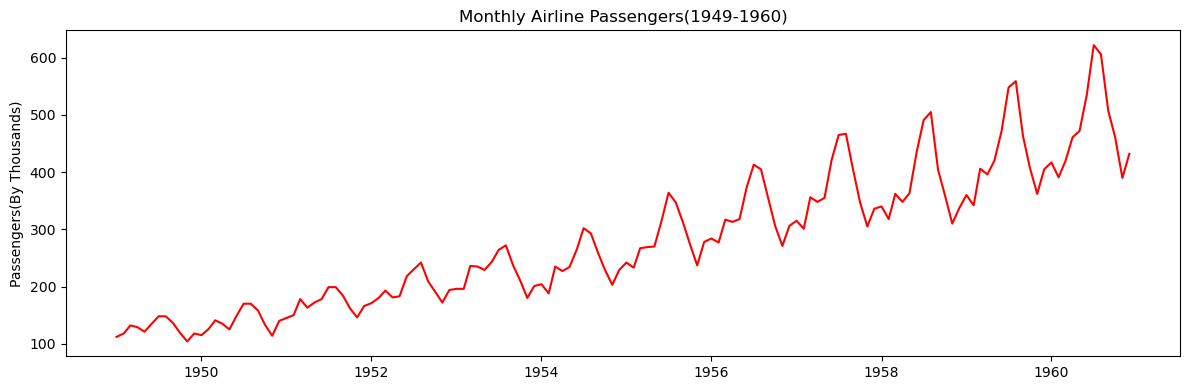

In [64]:
plt.figure(figsize=(12,4))
plt.plot(TS_1, color="red")
plt.title("Monthly Airline Passengers(1949-1960)")
plt.ylabel("Passengers(By Thousands)")
plt.tight_layout()
plt.show()

#We can see that the model is multiplicative and there is seasonlity
#The model grows each period which suggest T x S x R

#since it's a multip_model then we shall apply the log proprety to linearize the serie, we want to stablize the variance and the errors.

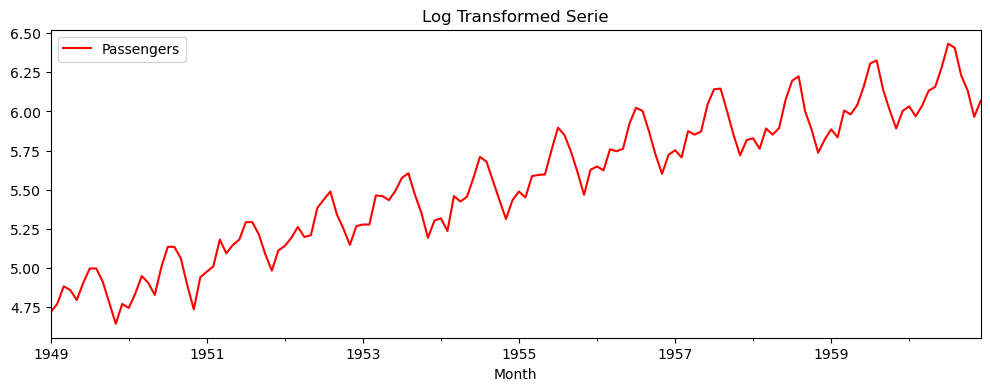

In [31]:
TS_1_log = np.log(TS_1)
TS_1_log.plot(title="Log Transformed Serie", figsize=(12,4), color='red')
plt.show()


#Let's decompose it, to have a further view on what's making the serie NS (non stationnary)

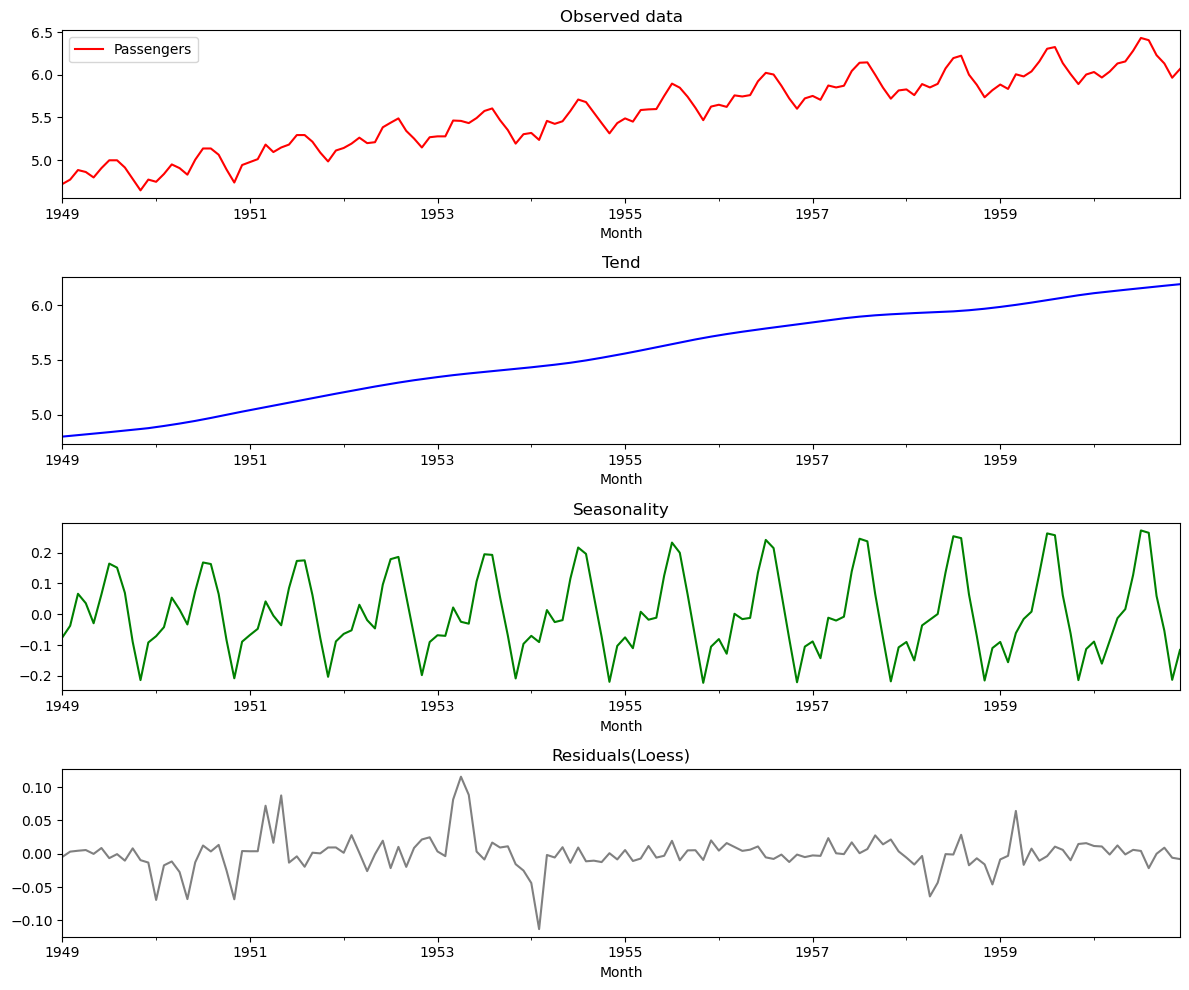

In [65]:
decomp_TS1 = STL(TS_1_log, period=12, robust=True).fit()

fig, ax = plt.subplots(4, 1, figsize=(12, 10))
decomp_TS1.observed.plot(ax=ax[0], title="Observed data", color='red')
decomp_TS1.trend.plot(ax=ax[1], title="Tend", color='blue')
decomp_TS1.seasonal.plot(ax=ax[2], title="Seasonality", color='green')
decomp_TS1.resid.plot(ax=ax[3], title="Residuals(Loess)", color='gray')
plt.tight_layout()
plt.show()

#except the residuals, both the trend and the observed data aren't, so we verify with a test

In [33]:
def adf_test(serie):
    result = adfuller(serie)
    print("ADF stat: ", result[0])
    print("ADF proba: ", result[1])
    if result[1] > 0.05:
        print("The serie is not stationnary")
    else:
        print('The serie is stationnary')

def kpss_test(serie):
    result = kpss(serie)
    print("KPSS STTA: ", result[0])
    print("KPSS proba: ", result[1])
    if result[1] < 0.05:
        print("The serie is not stationnary")
    else:
        print('The serie is stationnary')

print("ADF TEST:")
adf_test(TS_1)

print("\nKPSS TEST:")
kpss_test(TS_1)

ADF TEST:
ADF stat:  0.8153688792060456
ADF proba:  0.991880243437641
The serie is not stationnary

KPSS TEST:
KPSS STTA:  1.6513122354165206
KPSS proba:  0.01
The serie is not stationnary


/tmp/ipykernel_5869/1584447204.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(serie)


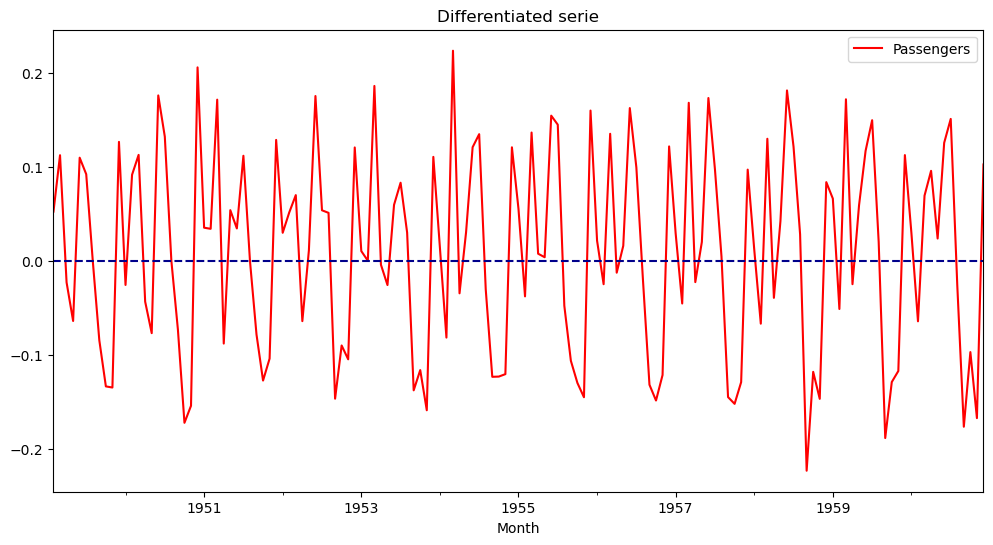

In [ ]:
#next move is to differtiate
#first degree diff
TS_diff = TS_1_log.diff().dropna()
TS_diff.plot(title="Differentiated serie", figsize=(12,6), color="red")
plt.axhline(y=0, color='darkblue', linestyle='--')
plt.show()

#seems stationnary in graph

#we verify again with tests

In [35]:
print("ADF TEST:")
adf_test(TS_diff)
print("\nKPSS TEST:")
kpss_test(TS_diff)


ADF TEST:
ADF stat:  -2.7171305983881626
ADF proba:  0.07112054815085377
The serie is not stationnary

KPSS TEST:
KPSS STTA:  0.03830446954674066
KPSS proba:  0.1
The serie is stationnary


/tmp/ipykernel_5869/1584447204.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(serie)


#We are seeing a contradiction between tests
#while ADF says that the serie isn't stationnary, kpss in the other hand says that it is stationnary
#but seeing p_val of adf (0.07, borderline) isn't far from being less than 0.05
#unlike p_val of the precedent test (0.99), it dropped significantly
#shall we conclude stationnarity? not that fast as one test contradicted it
#even if it dropped significantly
#we need both tests to say "the serie is stationnary"

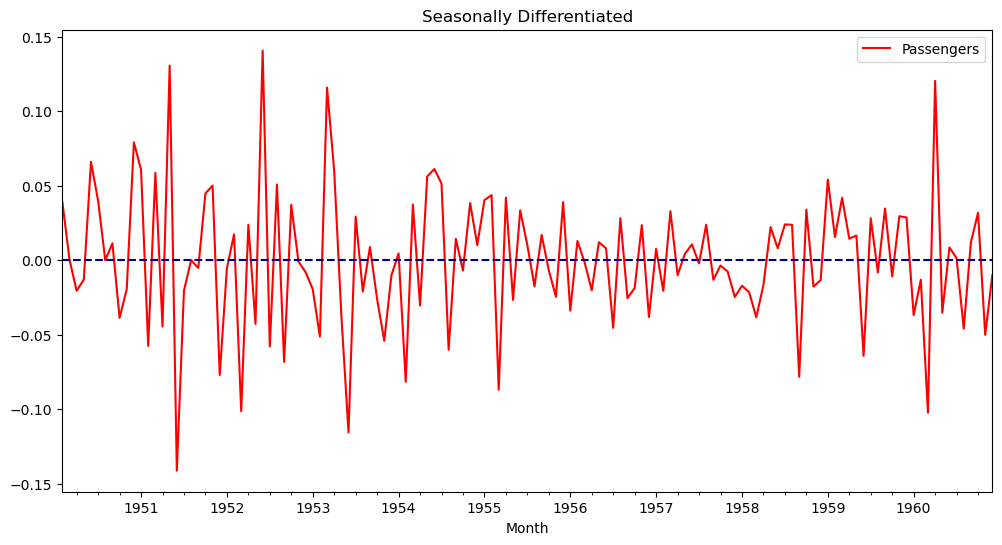

In [36]:
TS_diff_s = TS_diff.diff(12).dropna()  # remove the seasonal cycle
TS_diff_s.plot(title="Seasonally Differentiated", figsize=(12,6), color="red")
plt.axhline(y=0, color='darkblue', linestyle='--')
plt.show()

In [37]:
print("ADF TEST:")
adf_test(TS_diff_s)

print("\nKPSS TEST:")
kpss_test(TS_diff_s)

ADF TEST:
ADF stat:  -4.443324941831116
ADF proba:  0.00024859123113841266
The serie is stationnary

KPSS TEST:
KPSS STTA:  0.07319096983125449
KPSS proba:  0.1
The serie is stationnary


/tmp/ipykernel_5869/1584447204.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(serie)


#if i'm not wrong, now we got it

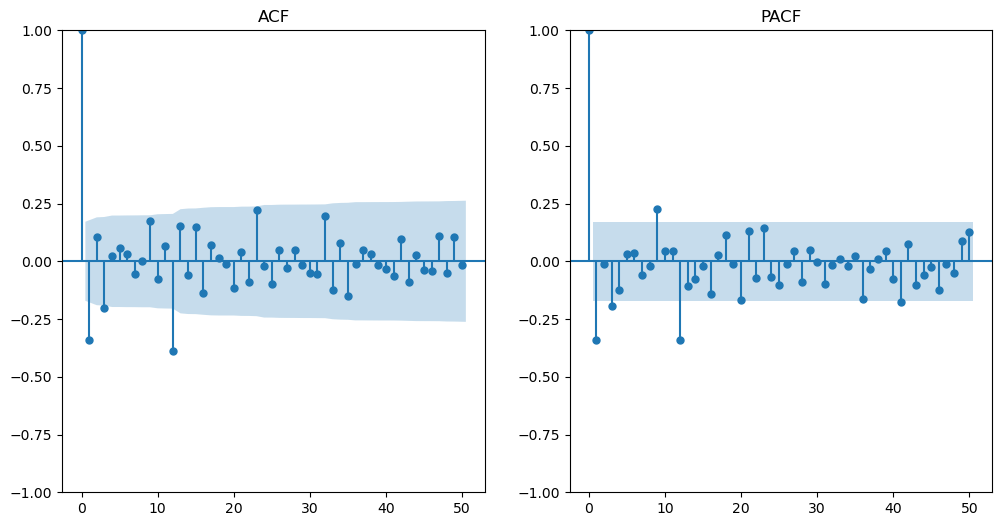

In [38]:
#let's plot autocorrelation and partia_autcorr
fig, ax = plt.subplots(1, 2, figsize=(12,6))

plot_acf(TS_diff_s, lags=50, ax=ax[0])
plot_pacf(TS_diff_s, lags=50, ax=ax[1])

ax[0].set_title("ACF")
ax[1].set_title("PACF")

plt.show()

In [67]:
model = SARIMAX(TS_1_log, order=(1,1,1))
results = model.fit()

results.summary()

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10
 This problem is unconstrained.

At X0         0 variables are exactly at the bounds

At iterate    0    f= -8.42804D-01    |proj g|=  2.54270D-01

At iterate    5    f= -8.43735D-01    |proj g|=  1.07314D-01

At iterate   10    f= -8.43955D-01    |proj g|=  2.10296D-01

At iterate   15    f= -8.53226D-01    |proj g|=  1.27461D+00

At iterate   20    f= -8.63285D-01    |proj g|=  7.15029D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    3     23     42      1     0     0   2.906D-05  -8.633D-01
  F = -0

/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             Passengers   No. Observations:                  144
Model:               SARIMAX(1, 1, 1)   Log Likelihood                 124.313
Date:                Sun, 03 May 2026   AIC                           -242.626
Time:                        12:31:33   BIC                           -233.738
Sample:                    01-01-1949   HQIC                          -239.014
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5773      0.164     -3.516      0.000      -0.899      -0.256
ma.L1          0.8478      0.098      8.686      0.000       0.656       1.039
sigma2         0.0103      0.002      5.992      0.000       0.007       0.014
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 5.94
Prob(Q):                              0.90   Prob(JB):                         0.05
Heteroskedasticity (H):               1.07   Skew:                             0.04
Prob(H) (two-sided):                  0.82   Kurtosis:                         2.00
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

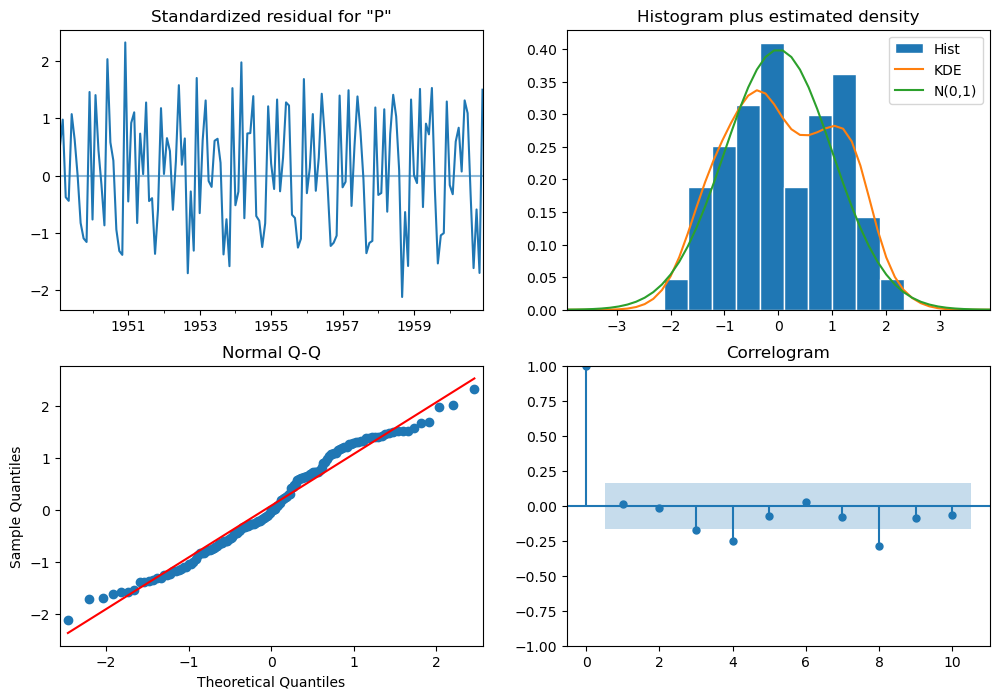

In [40]:
results.plot_diagnostics(figsize=(12,8))
plt.show()

#our residuals looks station

#the histogram almost tends to a normla distro

#but the correlogram still hase some spikes out of the CI 

In [ ]:
results = []

for p in range(2):
    for q in range(2):
        for P in range(2):
            for Q in range(2):
                model = SARIMAX(TS_1_log, 
                order=(p,1,q),
                seasonal_order=(P,1,Q,12))
                resul = model.fit()
                results.append((p,q,P,Q, resul.aic, resul.bic))
                print(f"Seasonal Order: p:{p}, d:1, q:{q}, P:{P}, D:1, Q:{Q}, 12")
                print(resul.aic, resul.bic)
resul_df = pd.DataFrame(results, columns=['p','q','P', 'Q', 'AIC', 'BIC'])
print(resul_df.sort_values(by="AIC").head())

/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            1     M =           10
 This problem is unconstrained.

At X0         0 variables are exactly at the bounds

At iterate    0    f= -1.51467D+00    |proj g|=  2.06816D+00

 Bad direction in the line search;
   refresh the lbfgs memory and restart the iteration.

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    1      4     47      2     0     0   7.217D-04  -1.517D+00
  F =  -1.5167707142770170     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             

   evaluations in the last line search.  Termination
   may possibly b

/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    2     11     26      1     0     0   3.243D-03  -1.601D+00
  F =  -1.6007455113665585     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             
Seasonal Order: p:0, d:1, q:0, P:1, D:1, Q:0, 12
-457.01470727356883 -451.26431262716653
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10
 This problem is unconstrained.

At X0         0 variables are exactly at the bounds

At iterate    0    f= -1.60759D+00    |proj g|=  5.05991D+00

At iterate    5    f= -1.61628D+00    |proj g|=  4.14739D-01

At iterate

/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


...

/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



At iterate   10    f= -1.67137D+00    |proj g|=  7.64056D-01

At iterate   15    f= -1.67166D+00    |proj g|=  8.62342D-02

At iterate   20    f= -1.67274D+00    |proj g|=  1.75916D-01

At iterate   25    f= -1.67308D+00    |proj g|=  1.22585D-01

At iterate   30    f= -1.67834D+00    |proj g|=  5.10863D-01

At iterate   35    f= -1.67868D+00    |proj g|=  2.45548D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    4     38     51      1     0     0   8.108D-04  -1.679D+00
  F =  -1.6786789734594685     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             
Seasonal Order: p:1, d:1, q:1, P:1, D:1, Q:0, 12
-4

/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



At iterate    5    f= -1.68179D+00    |proj g|=  8.28270D-01

At iterate   10    f= -1.69019D+00    |proj g|=  8.59724D-02

At iterate   15    f= -1.69036D+00    |proj g|=  3.23923D-01

At iterate   20    f= -1.69687D+00    |proj g|=  7.92638D-01

At iterate   25    f= -1.69770D+00    |proj g|=  3.58943D-01

At iterate   30    f= -1.69799D+00    |proj g|=  6.27086D-02

At iterate   35    f= -1.70136D+00    |proj g|=  2.74289D-01

At iterate   40    f= -1.70243D+00    |proj g|=  4.21752D-02

At iterate   45    f= -1.70244D+00    |proj g|=  4.99251D-03

At iterate   50    f= -1.70244D+00    |proj g|=  4.25905D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tn

/usr/lib/python3/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


#smallest AIC AND BIC (Focus more on BIC)

In [49]:
new_model = SARIMAX(TS_1_log, order=(1,1,0), seasonal_order=(0,1,1,12))
result_NewModel = new_model.fit()

result_NewModel.summary()

/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10
 This problem is unconstrained.

At X0         0 variables are exactly at the bounds

At iterate    0    f= -1.66847D+00    |proj g|=  4.87952D+00

At iterate    5    f= -1.68294D+00    |proj g|=  3.28697D-01

At iterate   10    f= -1.69198D+00    |proj g|=  1.22833D+00

At iterate   15    f= -1.69258D+00    |proj g|=  8.59377D-02

At iterate   20    f= -1.69265D+00    |proj g|=  6.92688D-03

 Bad direction in the line search;
   refresh the lbfgs memory and restart the iteration.

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                           Passengers   No. Observations:                  144
Model:             SARIMAX(1, 1, 0)x(0, 1, [1], 12)   Log Likelihood                 243.742
Date:                              Sun, 03 May 2026   AIC                           -481.484
Time:                                      12:24:16   BIC                           -472.858
Sample:                                  01-01-1949   HQIC                          -477.979
                                       - 12-01-1960                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3391      0.069     -4.891      0.000      -0.475      -0.203
ma.S.L12      -0.5622      0.094     -5.997      0.000      -0.746      -0.378
sigma2         0.0014      0.000      8.656      0.000       0.001       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.06   Jarque-Bera (JB):                 1.09
Prob(Q):                              0.81   Prob(JB):                         0.58
Heteroskedasticity (H):               0.56   Skew:                             0.05
Prob(H) (two-sided):                  0.06   Kurtosis:                         3.44
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

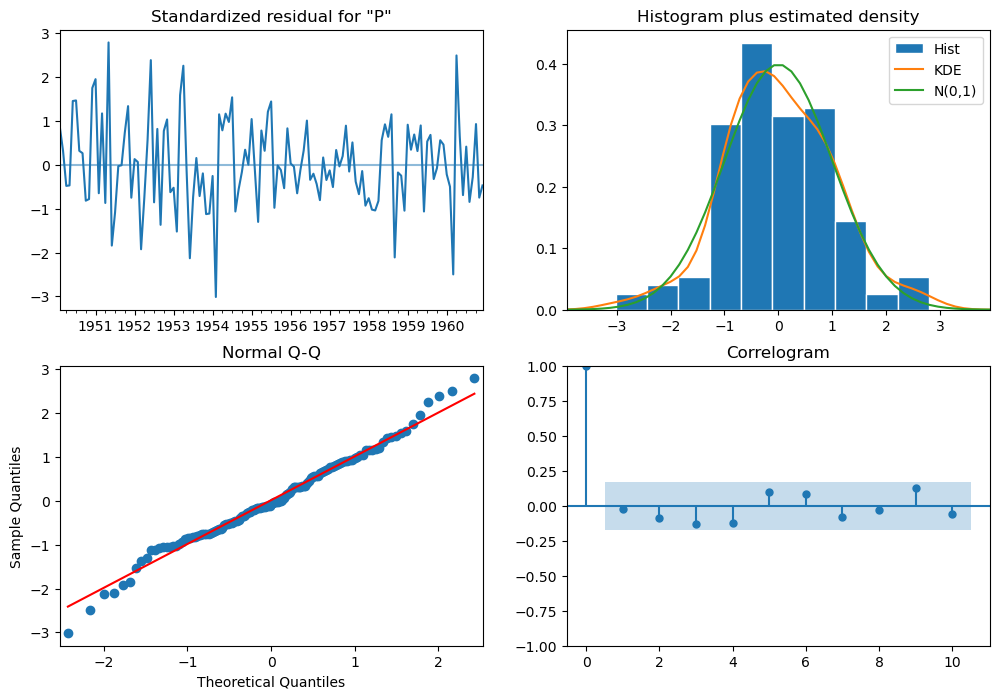

In [73]:
result_NewModel.plot_diagnostics(figsize=(12,8))
plt.show()

#the model is now ready to be used for forcast as it passed the diagnostics

In [74]:
#we split our data
Train_s = int(len(TS_1) * 0.8) #80% training

train = TS_1[:Train_s]
test = TS_1[Train_s:]

In [75]:
Sarimax_Model = SARIMAX(np.log(train), 
                        order=(1,1,0),
                        seasonal_order=(0,1,1,12))
result_SM = Sarimax_Model.fit()

/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/lib/python3/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10
 This problem is unconstrained.

At X0         0 variables are exactly at the bounds

At iterate    0    f= -1.61472D+00    |proj g|=  4.99772D+00

At iterate    5    f= -1.63108D+00    |proj g|=  2.46189D-01

At iterate   10    f= -1.63943D+00    |proj g|=  2.49867D+00

At iterate   15    f= -1.64285D+00    |proj g|=  7.82118D-03

At iterate   20    f= -1.64289D+00    |proj g|=  2.92021D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    3     21     32      1     0     0   3.092D-03  -1.643D+00
  F =  -

In [ ]:
forcasting = result_SM.get_forecast(steps=len(test))

prediction_mean = np.exp(forcasting.predicted_mean)
conf_int = np.exp(forcasting.conf_int())

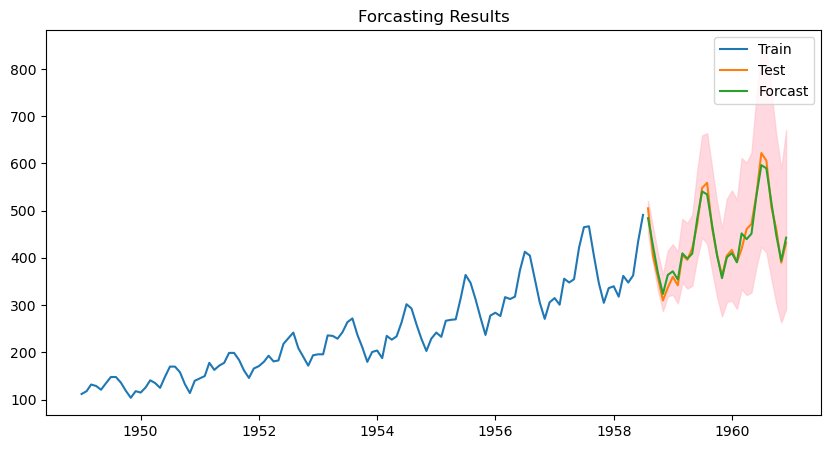

In [90]:
#ploting train,test,predicted_res
plt.figure(figsize=(10,5))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(prediction_mean, label="Forcast")

#Confidence_interval
plt.fill_between(conf_int.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 color='pink', alpha=0.6)

plt.legend()
plt.title("Forcasting Results")
plt.show()

In [91]:
MAE = mean_absolute_error(test, prediction_mean)
RMSE = np.sqrt(mean_squared_error(test, prediction_mean))

print("MAE:", MAE)
print("RMSE:", RMSE)

MAE: 12.173553169217005
RMSE: 14.925416886035038
